Looking across all conditions and sessions for all mice at:  
- fraction of tuned cells
- peak z-score of tuned cells
- std of tuning of tuned cells
- number of homings

In [40]:
%load_ext autoreload
%autoreload 2

from databank import full_experiments_objects
from behave_analysis.process.process import Process
from settings.settings_overrides import settings_overrides
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check
from settings.settings_analyze_efizz import Settings_ae
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import compute_tuning_stat
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
import os

%matplotlib inline

tuning_settings = {'ep_bins': 25,
                    'ep_no_stationary': False,
                    'ep_interpolation_mult': 2,
                    'ep_gaussian_fitting': False,
                    'ep_compute_loo_reliability': False,
                    'ep_tuned_compare_method': 'euclidean',
                    'ep_tuned_stats': 'bootstrap',
                    'ep_tuned_stats_samples': 100,
                    'linshift_min_step': 120,
                    'linshift_step': 80,
                    'linshift_step_n': 100,
                    'stim_type': 'audio',
                    'cluster_type': 'good',
                    'cluster_labels': "bombcell",
                    "homings": 'auto',
                    'condition_types': 'experimental_conditions',
                    'compartment_split': ['all'],
                    'redo_compute': False}
Settings_ae = settings_overrides(Settings_ae, tuning_settings)

h_settings = {"homings_speed_threshold": 4.0,  # cm/s, used to find bouts of running that may be homings
            "homings_gap_tolerance": 1,  # frames, used to merge bouts
            "homings_features_initial_window_s": 1.0,  # seconds, used to compute initial features of homings like acceleration and hdir change
            "homing_classification_target_recall": 0.9,  # minimum recall for a gate to be considered valid
            "homings_classification_recall_threshold": 0.9,  # minimum recall for a feature gate to be considered valid
            "homings_classification_precision_threshold": 0.1,  # minimum precision for a feature gate to be considered valid
            "homings_classification_auc_threshold": 0.9,  # or .8, minimum AUC for a feature gate to be considered valid
            "homings_classification_cohens_d_threshold": 1,  # minimum absolute Cohen's d for a feature gate to be considered valid
            "redo_compute": False,
            "homings_use_boris": False,
            "homings_curated": False,
            "homings_distance_threshold": 25  # in cm, minimum length to be kept as a homings
            }
from settings.settings_analyze_behave import settings_ab
settings_ab = settings_overrides(settings_ab, h_settings)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
"""Which homings do we use to compute the tuning?"""
# also, do all sessions have double peaked cells?
time_period = 'homing&escape' # 'homing&escape', 'correct_full_homing&escape' and 'to_subgoal_homing&escape'
var = 'frac_route in ' + time_period  
qualifier = "_bc"

In [ ]:
"""Changes in tuning over time"""
# 1. load in the tuning data for that session - which do we use? the canonical long homings one?

# loop over sessions, for each mouse look at the sessions in order
results_dict = {"mouse": [], "date": [], "sig_cells": {}, "mean_peak_zscore": {}, "mean_std": {}, "std": {}, "peak_zscore": {}}
for exp in full_experiments_objects:
    session = Process(exp).load_session()

    settings_dict = {"variable": var, 
                    "insufficient_data": False, 
                    **settings_to_check(Settings_ae, ["ep_"])}
    savepath = os.path.join(session['base_path'], session['processed_path'], "models", "escape_tuning")
        
    database, do_analysis, hexaname = check_database_for_same_run(settings_dict, 
                                                                    savepath + os.sep + "EscapePattern_results.csv", 
                                                                    Settings_ae)
    if do_analysis:
        print("No matching results found in database.Try another session!.")
        continue

    # load escape tuning
    data_file = os.path.join(savepath, f"EPtuning_{hexaname}_results.npz")
    ep_data = np.load(data_file, allow_pickle=True)
    real_stat, shift_stat = compute_tuning_stat(stat='zscore_peak', 
                                                shifted_matrix=ep_data['fr_shift'], 
                                                shift0=int(np.shape(ep_data['fr_shift'])[0] / 2), 
                                                neural_matrix=ep_data['neural_matrix'], 
                                                condition=ep_data['condition_vector'])
    sig_cells = real_stat > np.nanpercentile(shift_stat, 95, axis=0)
    frac_sig_cells = np.sum(sig_cells, axis=1) / sig_cells.shape[1]
    results_dict["mouse"].append(exp.nick_name)
    results_dict["date"].append(exp.experiment_date)
    cond_list = list(ep_data['all_conditions'])
    for c in cond_list:
        if c not in results_dict["sig_cells"].keys():
            results_dict["sig_cells"][c] = list(np.full(len(results_dict["mouse"])-1, np.nan))
            results_dict["mean_peak_zscore"][c] = list(np.full(len(results_dict["mouse"])-1, np.nan))
            results_dict["mean_std"][c] = list(np.full(len(results_dict["mouse"])-1, np.nan))
            results_dict["std"][c] = [[np.nan] for _ in range(len(results_dict["mouse"])-1)]
            results_dict["peak_zscore"][c] = [[np.nan] for _ in range(len(results_dict["mouse"])-1)]

    # frac sig cells per condition
    for c in results_dict["sig_cells"].keys():
        if c in cond_list:
            results_dict["sig_cells"][c].append(frac_sig_cells[cond_list.index(c)])
        else:
            results_dict["sig_cells"][c].append(np.nan)

    # z score and std tuning heatmaps
    if os.path.exists(os.path.join(session['base_path'], session['processed_path'], "frame_by_good_cluster_matrix" + qualifier + ".npy")):
        fcm = np.load(os.path.join(session['base_path'], session['processed_path'], "frame_by_good_cluster_matrix" + qualifier + ".npy"))
    else:
        fcm = np.load(os.path.join(session['base_path'], session['processed_path'], "frame_by_good_cluster_matrix.npy"))
    mean_fcm = np.nanmean(fcm, axis=0)
    std_fcm = np.nanstd(fcm, axis=0)
    for c in results_dict["sig_cells"].keys():
        if c in cond_list:
            i = cond_list.index(c)
            sig_mask = sig_cells[i, :]
            if int(np.sum(sig_mask)) > 0:
                tuning_hm = ep_data['fr_full'][i, sig_mask, :]
                tuning_hm = np.divide(
                    tuning_hm - mean_fcm[sig_mask, np.newaxis],
                    std_fcm[sig_mask, np.newaxis],
                    out=np.zeros_like(tuning_hm, dtype=np.float64),
                    where=std_fcm[sig_mask, np.newaxis] != 0
                )
                results_dict["mean_peak_zscore"][c].append(np.nanmean(np.nanmax(tuning_hm, axis=1)))
                results_dict["mean_std"][c].append(np.nanmean(np.nanstd(ep_data['y_fitted_full'][i, sig_mask, :], axis=1)))
                results_dict["std"][c].append([np.nanstd(ep_data['y_fitted_full'][i, sig_mask, :], axis=1)])
                results_dict["peak_zscore"][c].append([np.nanmax(tuning_hm, axis=1)])
            else:
                results_dict["mean_peak_zscore"][c].append(0)
                results_dict["mean_std"][c].append(0)
                results_dict["std"][c].append([np.zeros(1)])
                results_dict["peak_zscore"][c].append([np.zeros(1)])
        else:
            results_dict["mean_peak_zscore"][c].append(np.nan)
            results_dict["mean_std"][c].append(np.nan)
            results_dict["std"][c].append([np.full(1, np.nan)])
            results_dict["peak_zscore"][c].append([np.full(1, np.nan)])

2026-08-14 19:12:30.090 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 6 matched results in database: ['287a2a6a19104af2' 'c847382f601b458e' 'cdd666166db941aa'
 '88134a1b1fb1428b' '09b804d3579245dd' 'eec098426b1b4bfe'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_baseline_2023_08_17T13_41_44\processed_data\models\escape_tuning\EscapePattern_results.csv
2026-08-14 19:12:33.453 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 6 matched results in database: ['ce3aad308b9a4d06' '17326fb7ca344f88' '67fc3a4fe9be4ab8'
 '35b148c8182c4289' '47145bbb44934628' 'f059a9089e504f8e'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_mushroom_2023_08_18T08_22_16\processed_data\models\escape_tuning\EscapePattern_results.csv
c:\users\jasmine\documents\github\jal2_subgoal_pipeline\behave_analysis\analyze\EscapePattern\escape_pattern_utils.py:416: RuntimeWarning: All-NaN sli

No matching results found in database.Try another session!.


2026-08-14 19:14:08.597 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 4 matched results in database: ['f6a6644444184454' '873334d4fcf445d4' '943d02ba0328458e'
 '0801efd6948d485c'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\escape_tuning\EscapePattern_results.csv
2026-08-14 19:14:20.220 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 4 matched results in database: ['25edf1c3fff640d7' '5e4998cb8a13452e' '119b25a282a440bd'
 '15c549f53b734ff7'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_3_2024_03_21T11_20_34\processed_data\models\escape_tuning\EscapePattern_results.csv
2026-08-14 19:14:34.162 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 5 matched results in database: ['2ec1e230fdce42a8' 'f6a5226fc3ec424f' '584c2e3

No matching results found in database.Try another session!.


2026-08-14 19:15:23.383 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 3 matched results in database: ['556ad9318fe84d0a' '1aa08591446d4d1b' 'bb8256ff2af5493a'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL007\JAL007_barrierflip2_2024_03_12T11_18_26\processed_data\models\escape_tuning\EscapePattern_results.csv
2026-08-14 19:15:38.270 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 3 matched results in database: ['3c153ccd103d4592' '0032d33342404c40' '0f7be8305b924add'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL007\JAL007_barrier_flip3_2024_03_15T11_20_19\processed_data\models\escape_tuning\EscapePattern_results.csv
2026-08-14 19:15:47.001 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 3 matched results in database: ['803b57c050c04e66' 'c2bd6ce0a4204f31' '4adda77e96a342a4'] in the folder Z:\Jasmine_Laurence\Expe

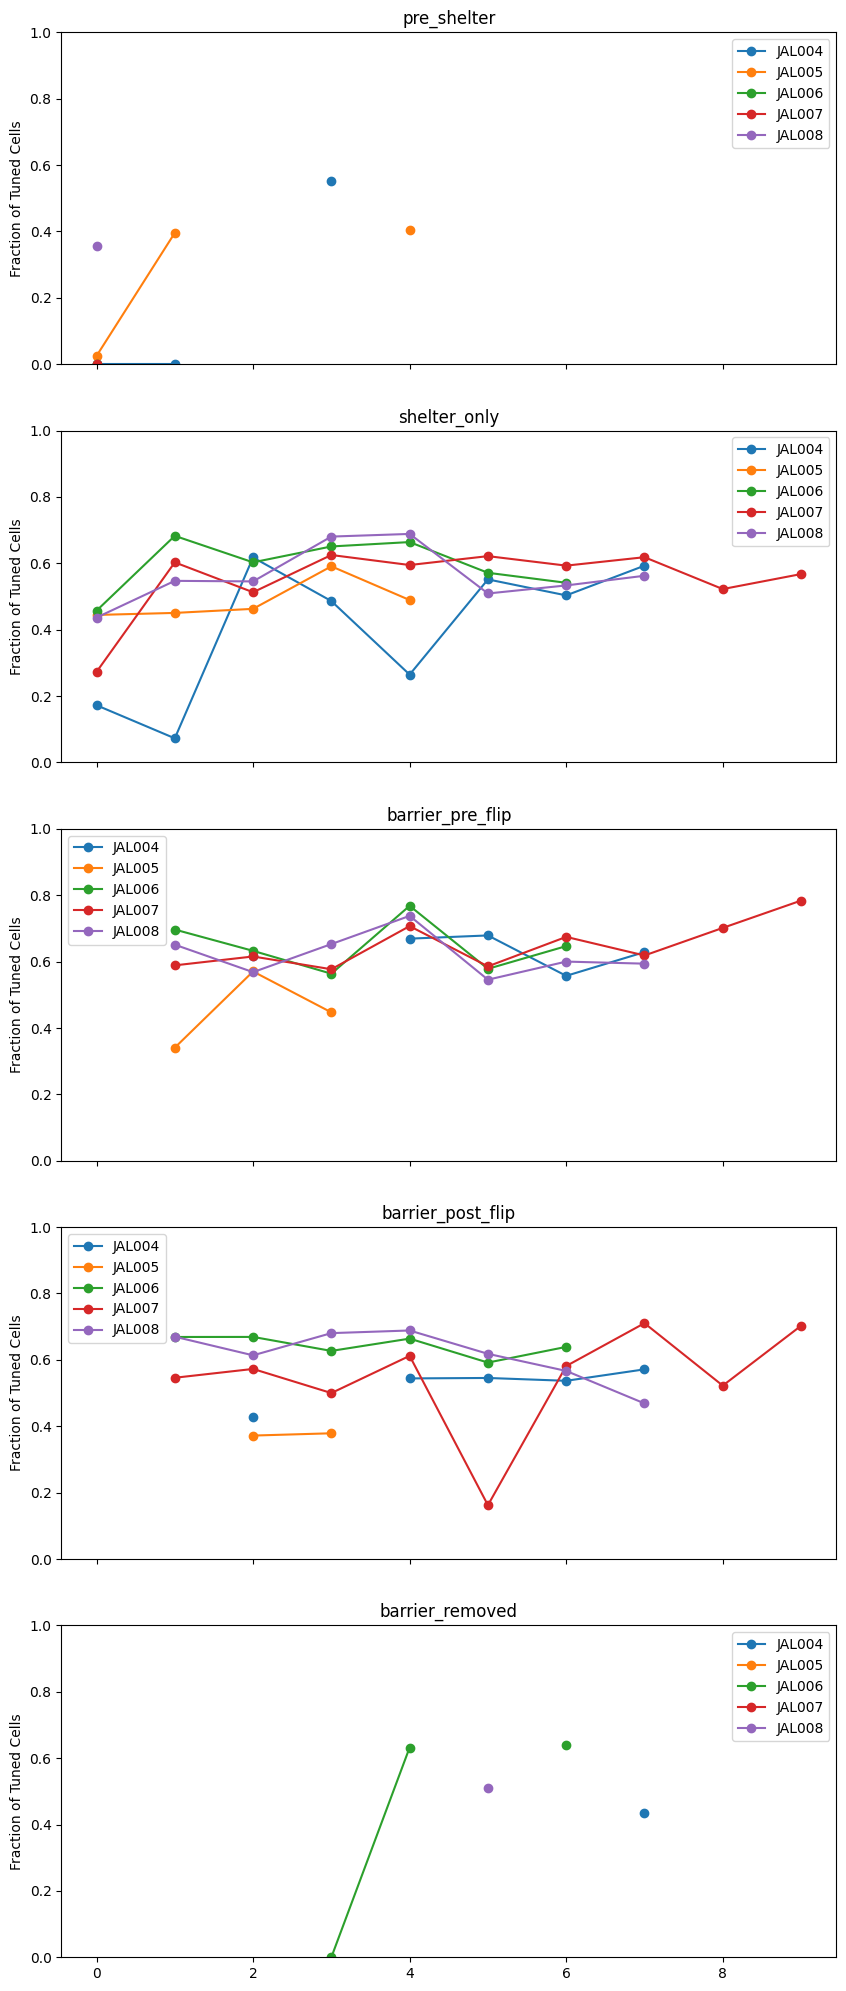

In [43]:
# 2. how many cells participate?
# iterate over conditions, and over mice and make one plot for each condition with the frac of cells tuned to that condition a separate line for each mouse x axis is ordered sessions
fig, axs = plt.subplots(len(results_dict["sig_cells"].keys()), 1, figsize=(10, 5*len(results_dict["sig_cells"].keys())), sharex=True)
for i, c in enumerate(results_dict["sig_cells"].keys()):
    mice = np.unique(results_dict["mouse"])
    for mouse in mice:
        mouse_idx = np.where(np.array(results_dict["mouse"]) == mouse)[0]
        dates = np.array(results_dict["date"])[mouse_idx]
        dt = pd.to_datetime(dates, format="%Y_%m_%d", errors="coerce")
        sort_idx = np.argsort(dt) # ascending
        axs[i].plot(np.array(results_dict["sig_cells"][c])[mouse_idx][sort_idx], label=mouse, marker='o')
    axs[i].set_title(c)
    axs[i].set_ylabel("Fraction of Tuned Cells")
    axs[i].set_ylim([0, 1])
    axs[i].legend()

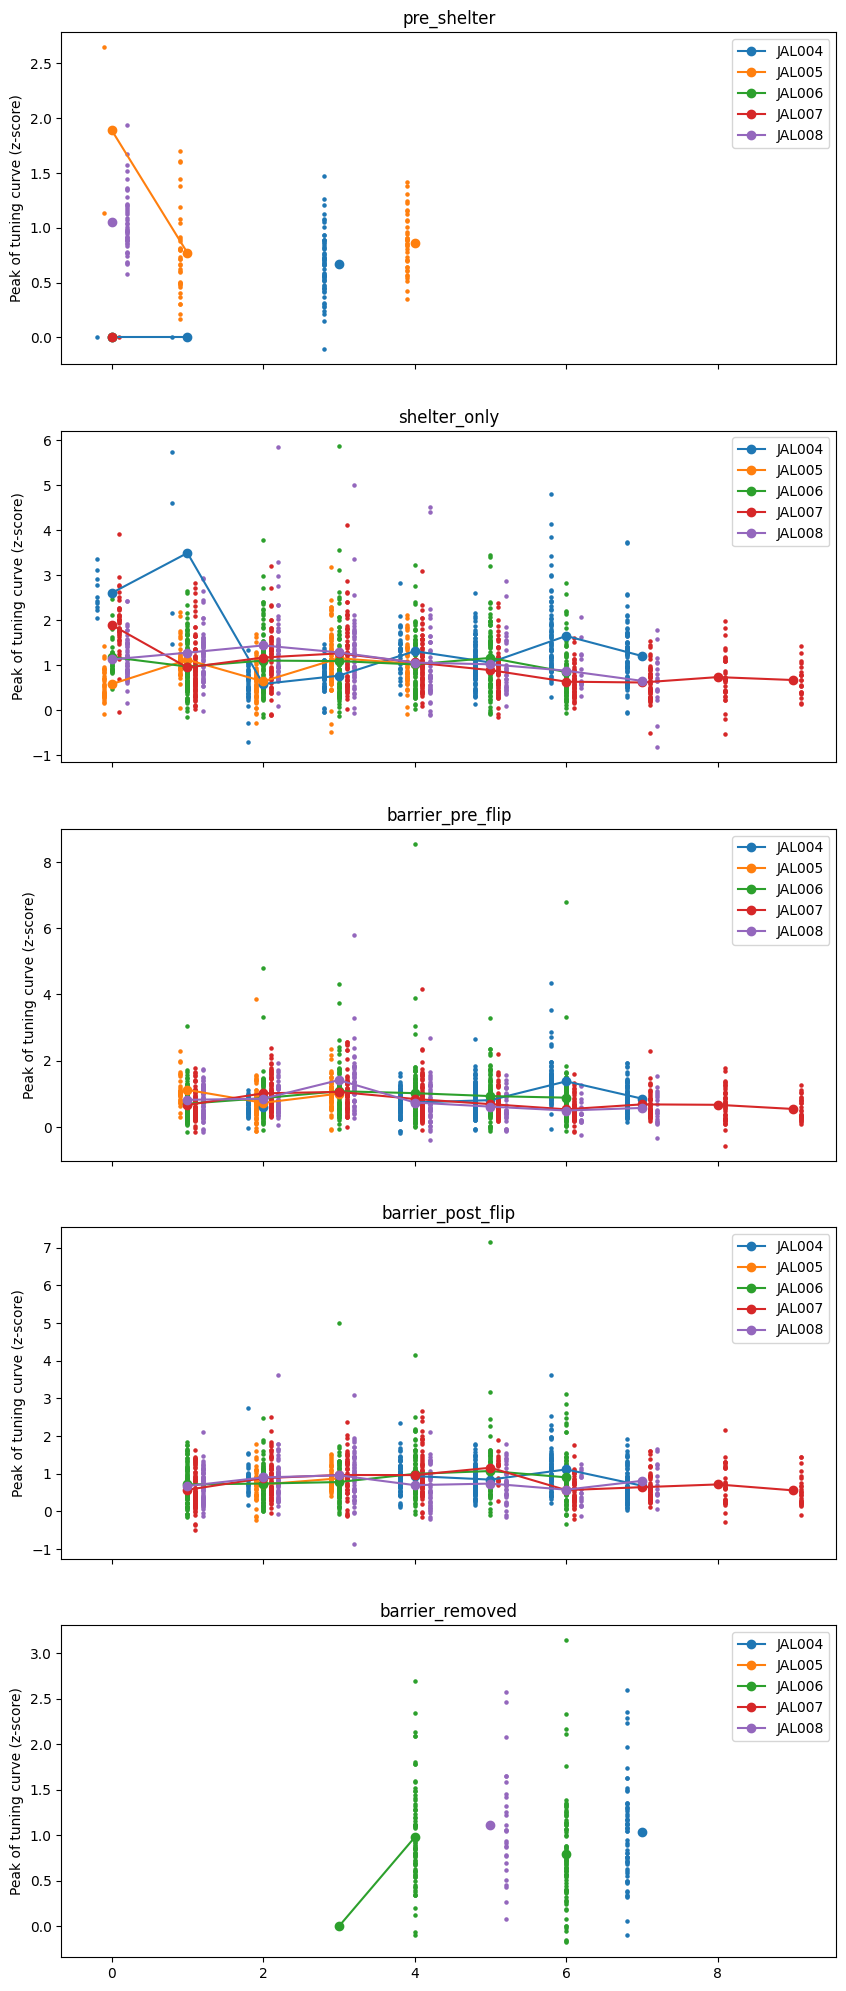

In [44]:
# 3. what is the z-score amplitude of the tuning curve
fig, axs = plt.subplots(len(results_dict["mean_peak_zscore"].keys()), 1, figsize=(10, 5*len(results_dict["mean_peak_zscore"].keys())), sharex=True)
mice = np.unique(results_dict["mouse"])
mouse_colors = {mouse: plt.cm.tab10(i) for i, mouse in enumerate(mice)}
mouse_offset = [-0.2, -0.1, 0, 0.1, 0.2]
for i, c in enumerate(results_dict["mean_peak_zscore"].keys()):
    for mouse in mice:
        mouse_idx = np.where(np.array(results_dict["mouse"]) == mouse)[0]
        dates = np.array(results_dict["date"])[mouse_idx]
        dt = pd.to_datetime(dates, format="%Y_%m_%d", errors="coerce")
        sort_idx = np.argsort(dt) # ascending
        axs[i].plot(np.array(results_dict["mean_peak_zscore"][c])[mouse_idx][sort_idx], label=mouse, marker='o', color=mouse_colors[mouse])
        for j, idx in enumerate(mouse_idx[sort_idx]):
            if not np.isnan(np.array(results_dict["peak_zscore"][c][idx][0])).all():
                axs[i].scatter((np.ones(len(results_dict["peak_zscore"][c][idx][0])) * j + mouse_offset[np.where(mice == mouse)[0][0]]), 
                               np.array(results_dict["peak_zscore"][c][idx]), 
                               s = 5, marker='o', color=mouse_colors[mouse])
    axs[i].set_title(c)
    axs[i].set_ylabel("Peak of tuning curve (z-score)")
    # axs[i].set_ylim([0, 2])
    axs[i].legend()

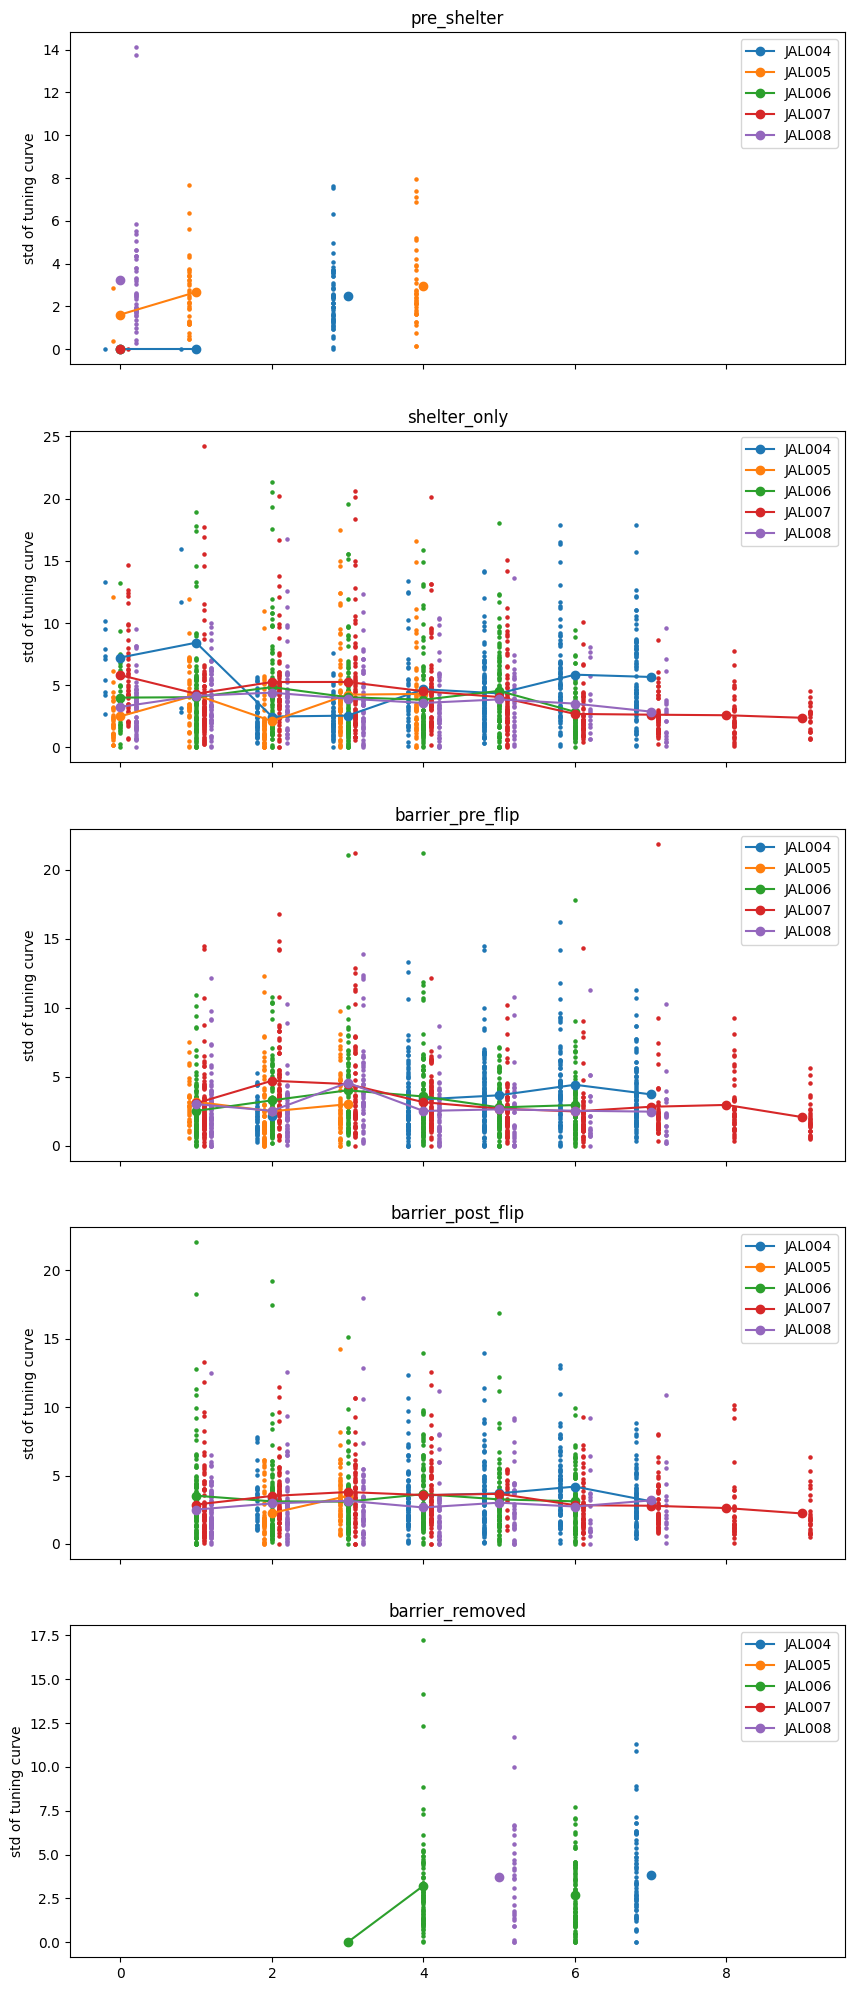

In [45]:
# 4. what is the std (FWHM) of the tuning curve?
fig, axs = plt.subplots(len(results_dict["mean_std"].keys()), 1, figsize=(10, 5*len(results_dict["mean_std"].keys())), sharex=True)
mice = np.unique(results_dict["mouse"])
mouse_colors = {mouse: plt.cm.tab10(i) for i, mouse in enumerate(mice)}
mouse_offset = [-0.2, -0.1, 0, 0.1, 0.2]
for i, c in enumerate(results_dict["mean_std"].keys()): 
    for mouse in mice:
        mouse_idx = np.where(np.array(results_dict["mouse"]) == mouse)[0]
        dates = np.array(results_dict["date"])[mouse_idx]
        dt = pd.to_datetime(dates, format="%Y_%m_%d", errors="coerce")
        sort_idx = np.argsort(dt) # ascending
        axs[i].plot(np.array(results_dict["mean_std"][c])[mouse_idx][sort_idx], label=mouse, marker='o', color=mouse_colors[mouse])
        for j, idx in enumerate(mouse_idx[sort_idx]):
            if not np.isnan(np.array(results_dict["std"][c][idx][0])).all():
                axs[i].scatter((np.ones(len(results_dict["std"][c][idx][0])) * j + mouse_offset[np.where(mice == mouse)[0][0]]), 
                               np.array(results_dict["std"][c][idx]),  
                               s = 5, marker='o', color=mouse_colors[mouse])
            
    axs[i].set_title(c)
    axs[i].set_ylabel("std of tuning curve")
    # axs[i].set_ylim([0, 6])
    axs[i].legend()

In [ ]:
"""Number of homings and some of their properties"""
from behave_analysis.analyze.behaviour.homings_escapes.homings_add_to_video_df import load_homing_for_aefizz
homing_type = "manual" # "auto", "auto_curated", "manual"
homing_results = {"mouse": [], "date": [], "num_homings": {}, "mean_homing_length_s": {}, "homing_length_s": {}}
for exp in full_experiments_objects:
    session = Process(exp).load_session()
    homing_dict = load_homing_for_aefizz(session, homing_type = homing_type)
    tuning_path = os.path.join(session['base_path'], session['processed_path'], "models", "escape_tuning", "EscapePattern_results.csv")
    csv = pd.read_csv(tuning_path)
    hexaname = csv["name"].to_numpy()[-1]
    data_file = os.path.join(session['base_path'], session['processed_path'], "models", "escape_tuning", f"EPtuning_{hexaname}_results.npz")
    ep_data = np.load(data_file, allow_pickle=True)
    cond_list = list(ep_data['all_conditions'])
    homing_results["mouse"].append(exp.nick_name)
    homing_results["date"].append(exp.experiment_date)
    for c in cond_list:
        if c not in homing_results["num_homings"].keys():
            homing_results["num_homings"][c] = list(np.full(len(homing_results["mouse"])-1, np.nan))
            homing_results["mean_homing_length_s"][c] = list(np.full(len(homing_results["mouse"])-1, np.nan))
            homing_results["homing_length_s"][c] = [[np.nan] for _ in range(len(homing_results["mouse"])-1)]

    # frac sig cells per condition
    for c in homing_results["num_homings"].keys():
        if c in cond_list:
            homing_results["num_homings"][c].append(np.sum(np.array(homing_dict["condition"]) == c))
            on = np.array(homing_dict["onset_frames"])[np.array(homing_dict["condition"]) == c]
            off = np.array(homing_dict["offset_frames"])[np.array(homing_dict["condition"]) == c]
            homing_results["homing_length_s"][c].append((off - on)/40)
            homing_results["mean_homing_length_s"][c].append([np.mean((off - on)/40)])
        else:
            homing_results["num_homings"][c].append(np.nan)
            homing_results["mean_homing_length_s"][c].append(np.full(1, np.nan))
            homing_results["homing_length_s"][c].append([np.nan])

2026-08-12 13:11:29.413 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.homings:__init__:43 - checking for existing homings results
2026-08-12 13:11:29.502 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.homings:get_homings:69 - Using manually labelled homings
2026-08-12 13:11:29.625 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.homing_load_manual_labels:load_manual_labels:21 - Loaded manual labels
2026-08-12 13:11:29.627 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.homing_load_manual_labels:load_manual_labels:22 - Number of homings: 3
2026-08-12 13:11:33.725 | INFO     | behave_analysis.analyze.results_database_utils:add_run_to_database:199 - Added run 403c76c62ac84c07 to database
2026-08-12 13:11:33.727 | SUCCESS  | behave_analysis.analyze.behaviour.homings_escapes.homings:save_session:117 - Homings saved
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mea

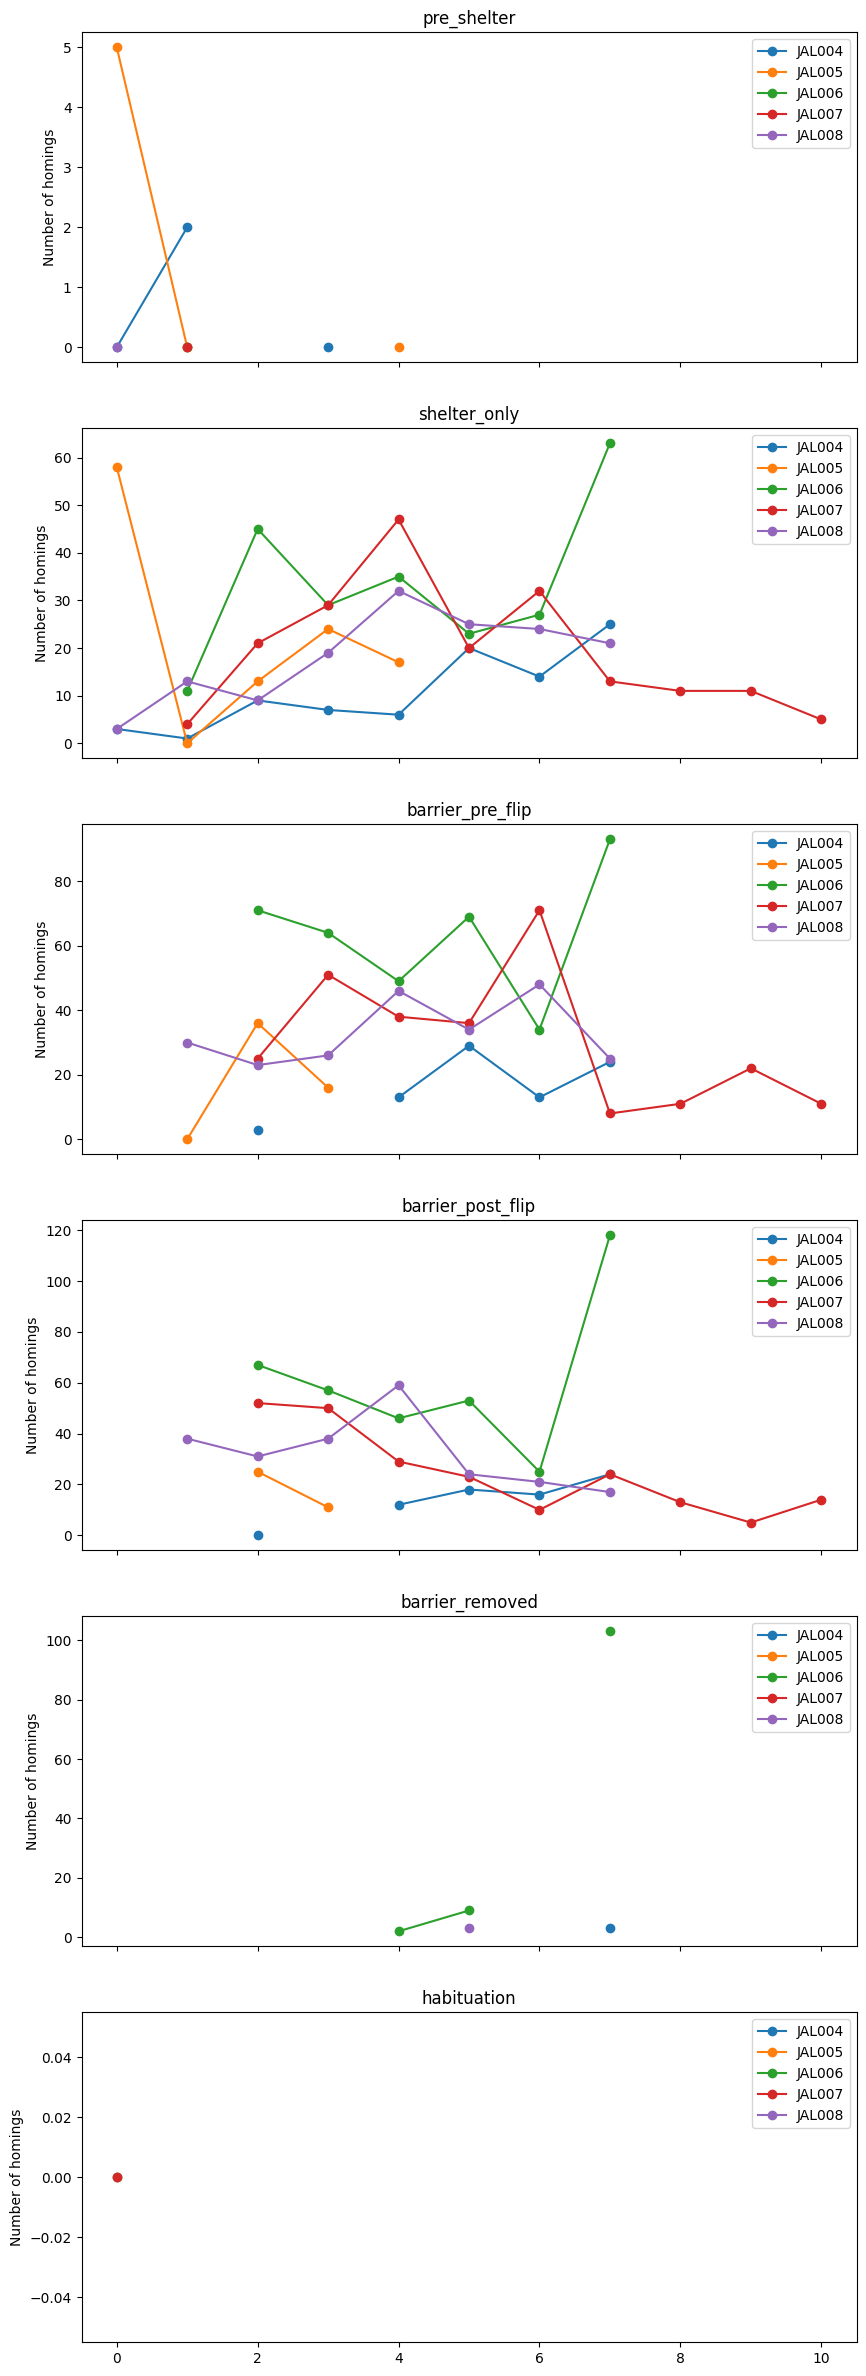

In [46]:
# 1 How many homings does the mouse perform
fig, axs = plt.subplots(len(homing_results["num_homings"].keys()), 1, figsize=(10, 5*len(homing_results["num_homings"].keys())), sharex=True)
for i, c in enumerate(homing_results["num_homings"].keys()):
    mice = np.unique(homing_results["mouse"])
    for mouse in mice:
        mouse_idx = np.where(np.array(homing_results["mouse"]) == mouse)[0]
        dates = np.array(homing_results["date"])[mouse_idx]
        dt = pd.to_datetime(dates, format="%Y_%m_%d", errors="coerce")
        sort_idx = np.argsort(dt) # ascending
        axs[i].plot(np.array(homing_results["num_homings"][c])[mouse_idx][sort_idx], label=mouse, marker='o')
    axs[i].set_title(c)
    axs[i].set_ylabel("Number of homings")
    # axs[i].set_ylim([0, 1])
    axs[i].legend()

In [39]:
homing_results["mean_homing_length_s"][c]

[[np.float64(nan)],
 [np.float64(2.3625)],
 nan,
 [np.float64(nan)],
 nan,
 nan,
 nan,
 nan,
 [np.float64(3.6100000000000003)],
 [np.float64(nan)],
 nan,
 nan,
 [np.float64(nan)],
 nan,
 [np.float64(nan)],
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 [np.float64(nan)],
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 [np.float64(nan)],
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan]

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (40,) + inhomogeneous part.

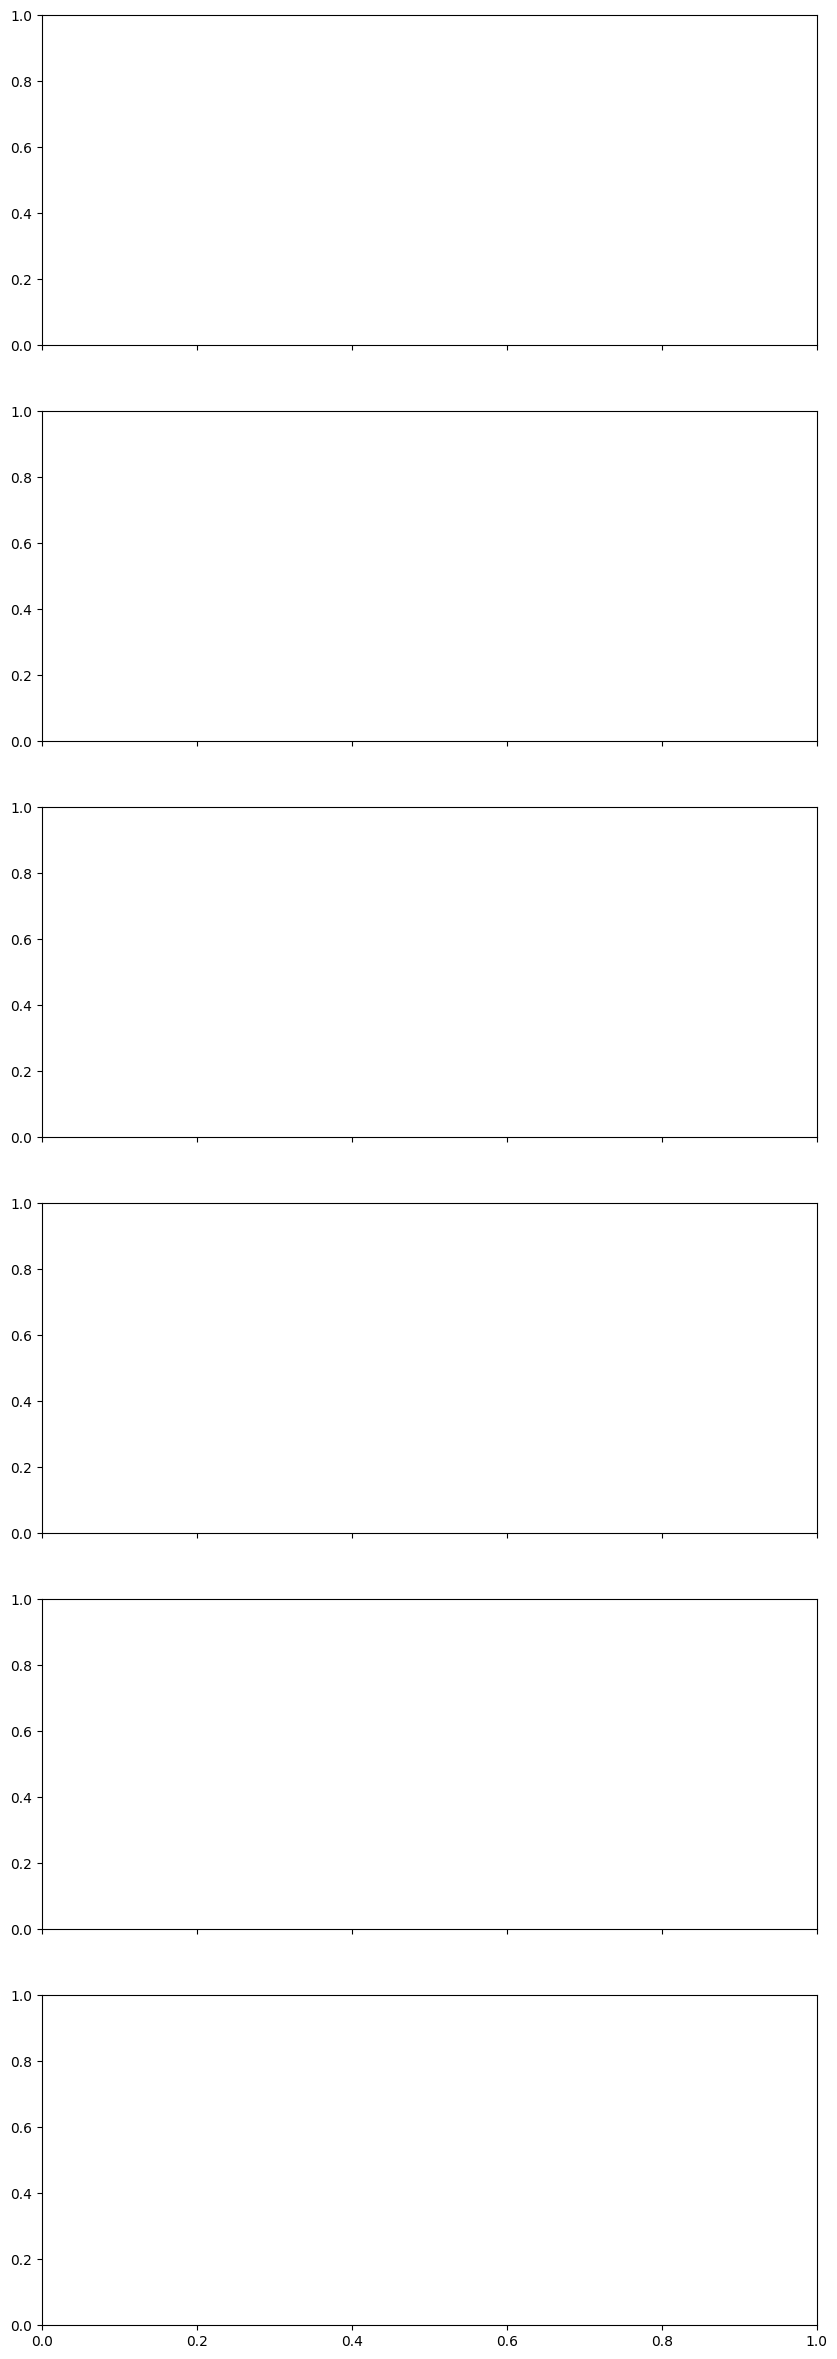

In [38]:
# 2. What is homing length in seconds?
fig, axs = plt.subplots(len(homing_results["mean_homing_length_s"].keys()), 1, figsize=(10, 5*len(homing_results["mean_homing_length_s"].keys())), sharex=True)
mice = np.unique(homing_results["mouse"])
mouse_colors = {mouse: plt.cm.tab10(i) for i, mouse in enumerate(mice)}
mouse_offset = [-0.2, -0.1, 0, 0.1, 0.2]
for i, c in enumerate(homing_results["mean_homing_length_s"].keys()): 
    for mouse in mice:
        mouse_idx = np.where(np.array(homing_results["mouse"]) == mouse)[0]
        dates = np.array(homing_results["date"])[mouse_idx]
        dt = pd.to_datetime(dates, format="%Y_%m_%d", errors="coerce")
        sort_idx = np.argsort(dt) # ascending
        axs[i].plot(np.array(homing_results["mean_homing_length_s"][c])[mouse_idx][sort_idx], label=mouse, marker='o', color=mouse_colors[mouse])
        for j, idx in enumerate(mouse_idx[sort_idx]):
            if not np.isnan(np.array(homing_results["homing_length_s"][c][idx][0])).all():
                axs[i].scatter((np.ones(len(homing_results["homing_length_s"][c][idx][0])) * j + mouse_offset[np.where(mice == mouse)[0][0]]), 
                               np.array(homing_results["homing_length_s"][c][idx]),  
                               s = 5, marker='o', color=mouse_colors[mouse])
            
    axs[i].set_title(c)
    axs[i].set_ylabel("Time in homing (s)")
    # axs[i].set_ylim([0, 6])
    axs[i].legend()

In [ ]:
"""Differences in behavioral state in homings and curvy runs"""
# what is speed across homing

# hdir in homing, as delta/hdir?

# hdir relative to heading angle

# do they terminate at shelter?